In [ ]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [ ]:
#Import the dataset
data = pd.read_csv('/content/data.csv')
data

,Sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [ ]:
data.describe() #Get statistical analytics

,Sno,Temperature,Pressure
count,6.000000,6.000000,6.000000
mean,3.500000,50.000000,0.066233
std,1.870829,37.416574,0.105467
min,1.000000,0.000000,0.000200
25%,2.250000,25.000000,0.002400
50%,3.500000,50.000000,0.018000
75%,4.750000,75.000000,0.075000
max,6.000000,100.000000,0.270000


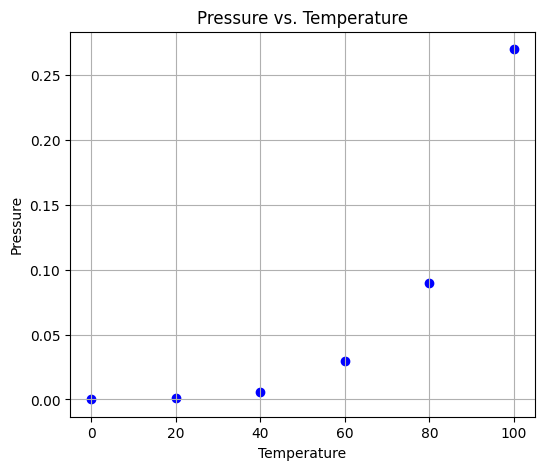

In [ ]:
#Plot a scatter plot for the dataset
plt.figure(figsize=(6, 5))
plt.scatter(data['Temperature'], data['Pressure'], color='blue')
plt.title('Pressure vs. Temperature')
plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.grid(True)
plt.show()

In [ ]:
#Define the features and target variables
X = data['Temperature'].values.reshape(-1, 1)
y = data['Pressure'].values

# LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,y)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = lr.predict(X)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error : {mse}")
print(f"R-squared : {r2}")

Mean Squared Error : 0.002870267555555557
R-squared : 0.690349972603981


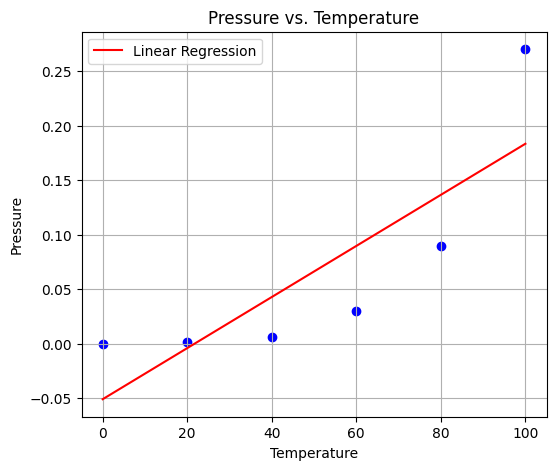

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(X, y, color='blue')
plt.plot(X, y_pred, color='red', label="Linear Regression")
plt.title('Pressure vs. Temperature')
plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.grid(True)
plt.legend()
plt.show()

# POLYNOMIAL REGRESSION

In [ ]:
#Generating polynomial features
degree = 4
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)
print(f"X_poly shape: {X_poly.shape}")

X_poly shape: (6, 5)


In [ ]:
#Perform regression on the dataset
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred2 = lin_reg.predict(X_poly)
mse = mean_squared_error(y, y_pred2)
r2 = r2_score(y, y_pred2)

print(f"Mean Squared Error : {mse}")
print(f"R-squared : {r2}")

Mean Squared Error : 2.863518518518477e-06
R-squared : 0.9996910780718014


In [ ]:
df = pd.DataFrame({'Actual Pressure': y, 'Predicted Pressure': y_pred})
df

,Actual Pressure,Predicted Pressure
0,0.0002,-0.050867
1,0.0012,-0.004027
2,0.0060,0.042813
3,0.0300,0.089653
4,0.0900,0.136493
5,0.2700,0.183333


In [ ]:
unseen_data = np.arange(-5, 105, 5).reshape(-1, 1) # Generate a range of unseen temperature values

unseen_data_poly = poly_features.transform(unseen_data) # Transform these unseen temperatures into polynomial features

unseen_predictions = lin_reg.predict(unseen_data_poly)# Predict pressure for the unseen data

unseen_df = pd.DataFrame({
    'Unseen Temperature': unseen_data.flatten(),
    'Predicted Pressure': unseen_predictions
})

print("Predictions on Unseen Data:")
print(unseen_df)

Predictions on Unseen Data:
    Unseen Temperature  Predicted Pressure
0                   -5            0.005228
1                    0            0.000461
2                    5           -0.001798
3                   10           -0.002274
4                   15           -0.001557
5                   20           -0.000106
6                   25            0.001759
7                   30            0.003848
8                   35            0.006105
9                   40            0.008611
10                  45            0.011578
11                  50            0.015354
12                  55            0.020419
13                  60            0.027389
14                  65            0.037012
15                  70            0.050173
16                  75            0.067887
17                  80            0.091306
18                  85            0.121714
19                  90            0.160532
20                  95            0.209311
21                 100    

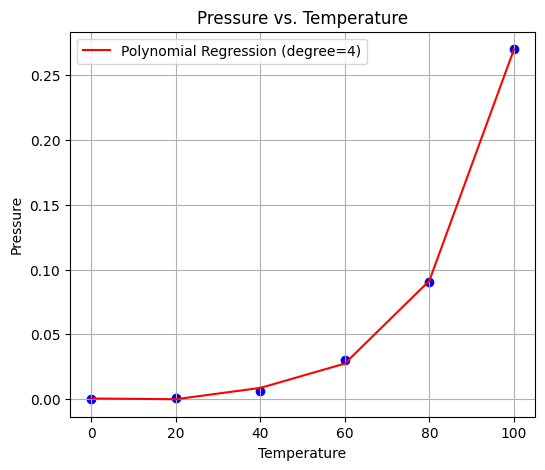

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(X, y, color='blue')
plt.plot(X, y_pred2, color='red', label=f'Polynomial Regression (degree={degree})')
plt.title('Pressure vs. Temperature')
plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.grid(True)
plt.legend()
plt.show()